In [59]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tabulate import tabulate

    - Function to format results into a table

In [60]:
# Custom function to display tables in a formatted way
def display_table(df: pd.DataFrame, title: str):
    """
    Display a formatted table for quick analysis and validation of results.

    Parameters
    ----------
    df (pd.DataFrame): DataFrame to be displayed.
    title (str): Title printed above the table.


    Returns
    -------
    df (pd.DataFrame)
    """

    print(f"\n{title}")
    if df is None:
        print("⚠️ No data provided.")
        return

    if isinstance(df, pd.Series):
        df = df.to_frame()

    if not isinstance(df, pd.DataFrame):
        print("⚠️ Invalid data format.")
        return

    if df.empty or df.shape[1] == 0:
        print("⚠️ No valid data or columns not found.")
        return

    colalign = ["center"] * len(df.columns)
    print(tabulate(df, headers="keys", tablefmt="fancy_grid", colalign=colalign, showindex=True, floatfmt=".8f"))

---

In [61]:
# Base directory where model results were saved
cache_dir = Path(r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código")

# Final test result folders
Models_paths = {"Naive": cache_dir / "Tese_ETS_results" / "Tese_Bitcoin_Naive_test_rolling_step10_h120_pkl",
                "ETS": cache_dir / "Tese_ETS_results" / "Tese_Bitcoin_Yeo-Johnson-Variance_ret(L)_ETS_test_rolling_step10_h120_pkl",
                "ARIMA": cache_dir / "Tese_ARIMA_results" / "Tese_Bitcoin_Yeo-Johnson-Variance_ret(L)_ARIMA_test_rolling_step10_h120_pkl",
                "ARCH": cache_dir / "Tese_ARCH_results" / "Tese_Bitcoin_Returns(L)_ARCH_test_rolling_step10_h120_pkl",
                "SVR": cache_dir / "Tese_SVR_results" / "Tese_Bitcoin_Variance_ret(L)_SVR_test_rolling_step10_h120_pkl",
                "LSTM": cache_dir / "Tese_LSTM_results" / "Tese_Bitcoin_Yeo-Johnson-Variance_ret(L)_LSTM_test_rolling_step10_h120_pkl"}

In [62]:
# Function to load Models test results
def load_model_test_result(model_name: str, folder_path: Path):
    """
    Load Models test_results.parquet from a saved cache folder and add the model name.
    """

    test_file = folder_path / "test_results.parquet"

    if not test_file.exists():
        raise FileNotFoundError(f"File not found: {test_file}")

    df = pd.read_parquet(test_file).copy()
    df.insert(0, "Model", model_name)

    return df

In [66]:
# Load and clean all final test results: Naive, ETS, ARIMA, ARCH, SVR, LSTM
model_test_frames = []

for model_name, folder_path in Models_paths.items():
    
    df_tmp = load_model_test_result(model_name, folder_path)
    
    # Safety check: ensure loaded object is a DataFrame
    if df_tmp is None or len(df_tmp) == 0:
        print(f"Warning: no results loaded for {model_name}")
        continue
    
    # Ensure that the model family is explicitly preserved
    df_tmp = df_tmp.copy()
    df_tmp["Model"] = model_name
    
    model_test_frames.append(df_tmp)

# Safety check before concatenation
if len(model_test_frames) == 0:
    raise ValueError("No model test results were loaded. Please check Models_paths and load_model_test_result().")

df_models_all = pd.concat(model_test_frames, ignore_index=True)
df_models_compare = df_models_all.copy()

# Add transformation used by each final model

transformation_map = {"Naive": "Original",
                      "ETS": "Yeo-Johnson",
                      "ARIMA": "Yeo-Johnson",
                      "ARCH": "None",
                      "SVR": "Original",
                      "LSTM": "Yeo-Johnson"}

df_models_compare["Transformation"] = (df_models_compare["Model"].astype(str).map(transformation_map))

# Keep only RMSE and QLIKE columns
rmse_cols = [col for col in df_models_compare.columns if "rmse" in col.lower()]
qlike_cols = [col for col in df_models_compare.columns if "qlike" in col.lower()]
metric_cols = rmse_cols + qlike_cols

# Safety check
if len(metric_cols) == 0:
    raise ValueError("No RMSE or QLIKE columns were found. Please check the column names in df_models_all.")

# Put mean/score columns at the end
mean_cols = [col for col in metric_cols if "mean" in col.lower() or "score" in col.lower()]
non_mean_metric_cols = [col for col in metric_cols if col not in mean_cols]

# Final column selection
final_cols = ["Model", "Transformation"] + non_mean_metric_cols + mean_cols
df_models_compare = df_models_compare[final_cols]

# Order models logically
model_order = ["Naive", "ETS", "ARIMA", "ARCH", "SVR", "LSTM"]

df_models_compare["Model"] = pd.Categorical(df_models_compare["Model"], categories=model_order, ordered=True)
df_models_compare = df_models_compare.sort_values("Model")

# Set Model as index
df_models_compare = df_models_compare.set_index("Model")

# Display final comparison table
display_table(df_models_compare, "Final test results across models - RMSE and QLIKE only")


Final test results across models - RMSE and QLIKE only
╒═════════╤══════════════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═══════════════════╤════════════════════╕
│  Model  │  Transformation  │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │  QLIKE-h=1   │  QLIKE-h=7   │  QLIKE-h=15  │  QLIKE-h=30  │  QLIKE-h=120  │  score_rmse_mean  │   score_qlike_mean │
╞═════════╪══════════════════╪════════════╪════════════╪═════════════╪═════════════╪══════════════╪══════════════╪══════════════╪══════════════╪══════════════╪═══════════════╪═══════════════════╪════════════════════╡
│  Naive  │     Original     │ 0.00102799 │ 0.00088119 │ 0.00075977  │ 0.00086042  │  0.00090332  │ 157.50267187 │ 646.44736462 │ 288.96638187 │ 64.27738579  │ 651.79337257  │    0.00088654     │       361.79743534 │
├─────────┼──────────────────┼────────────┼────────────┼─────────────┼──────

In [67]:
# Create a compact table with only mean RMSE and mean QLIKE
df_tmp = df_models_compare.copy()
df_tmp = df_tmp.reset_index()

# Columns to keep
final_cols = ["Model", "Transformation", "score_rmse_mean", "score_qlike_mean"]

# Safety check
missing_cols = [col for col in final_cols if col not in df_tmp.columns]

if missing_cols:
    raise ValueError(f"The following required columns are missing: {missing_cols}")

# Select only mean metrics
df_models_mean_compare = df_tmp[final_cols].copy()

# Rename columns for thesis-style display
df_models_mean_compare = df_models_mean_compare.rename(columns={"score_rmse_mean": "Mean RMSE", "score_qlike_mean": "Mean QLIKE"})

# Order models logically
model_order = ["Naive", "ETS", "ARIMA", "ARCH", "SVR", "LSTM"]

df_models_mean_compare["Model"] = pd.Categorical(df_models_mean_compare["Model"], categories=model_order, ordered=True)

df_models_mean_compare = df_models_mean_compare.sort_values("Model")

# Set Model as index
df_models_mean_compare = df_models_mean_compare.set_index("Model")

# Display final compact table
display_table(df_models_mean_compare, "Final test results across models - mean RMSE and mean QLIKE")


Final test results across models - mean RMSE and mean QLIKE
╒═════════╤══════════════════╤═════════════╤══════════════╕
│  Model  │  Transformation  │  Mean RMSE  │   Mean QLIKE │
╞═════════╪══════════════════╪═════════════╪══════════════╡
│  Naive  │     Original     │ 0.00088654  │ 361.79743534 │
├─────────┼──────────────────┼─────────────┼──────────────┤
│   ETS   │   Yeo-Johnson    │ 0.00059421  │  -3.83786528 │
├─────────┼──────────────────┼─────────────┼──────────────┤
│  ARIMA  │   Yeo-Johnson    │ 0.00059495  │  -3.35446781 │
├─────────┼──────────────────┼─────────────┼──────────────┤
│  ARCH   │       None       │ 0.00092927  │  -6.27993194 │
├─────────┼──────────────────┼─────────────┼──────────────┤
│   SVR   │     Original     │ 0.00059057  │  -5.03317852 │
├─────────┼──────────────────┼─────────────┼──────────────┤
│  LSTM   │   Yeo-Johnson    │ 0.00059114  │  -4.63086064 │
╘═════════╧══════════════════╧═════════════╧══════════════╛


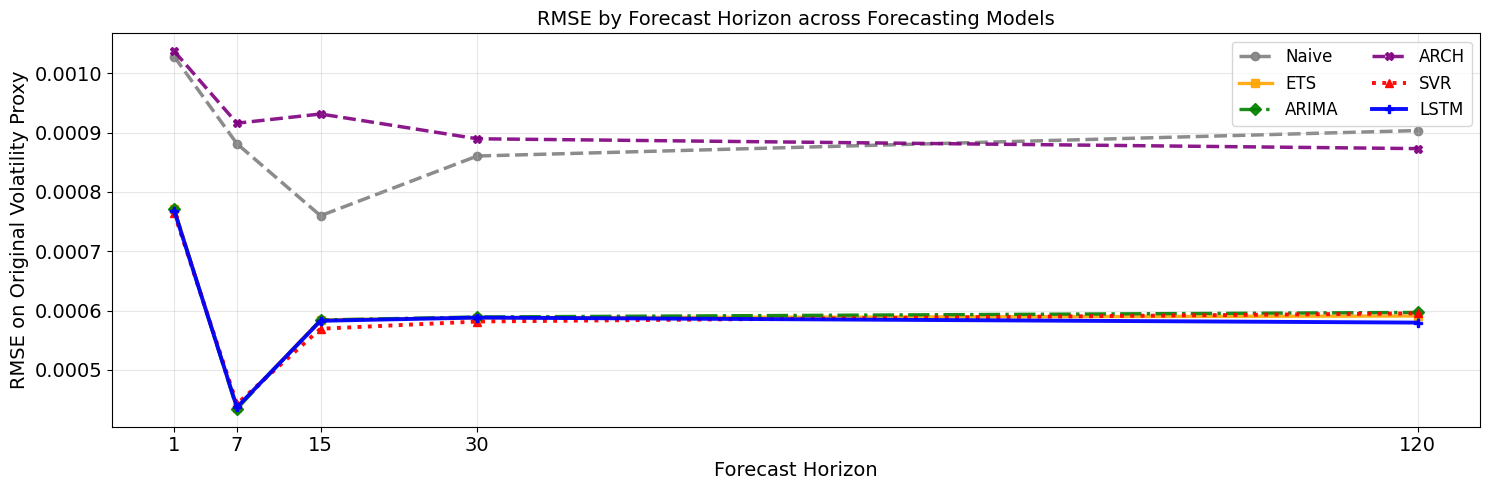

In [68]:
# Plot RMSE by forecast horizon across forecasting models
def plot_models_rmse_by_horizon(df_compare: pd.DataFrame):
    """
    Plot RMSE by forecast horizon across forecasting models.
    """

    df_plot = df_compare.copy()
    df_plot = df_plot.reset_index()

    # Select RMSE columns by horizon
    horizon_cols = sorted([c for c in df_plot.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))

    if len(horizon_cols) == 0:
        raise ValueError("No RMSE horizon columns found. Expected columns like 'RMSE-h=1', 'RMSE-h=7', etc.")

    horizons = [int(c.split("=")[1]) for c in horizon_cols]

    # Logical model order
    model_order = ["Naive", "ETS", "ARIMA", "ARCH", "SVR", "LSTM"]

    df_plot["Model"] = pd.Categorical(df_plot["Model"], categories=model_order, ordered=True)

    df_plot = df_plot.sort_values("Model")

    plt.figure(figsize=(15, 5))

    plot_styles = {"Naive": {"marker": "o", "linestyle": "--", "linewidth": 2.5, "alpha": 0.9, "zorder": 1, "color": "gray"},
                   "ETS": {"marker": "s", "linestyle": "-", "linewidth": 2.4, "alpha": 0.9, "zorder": 2, "color": "orange"},
                   "ARIMA": {"marker": "D", "linestyle": "-.", "linewidth": 2.4, "alpha": 0.9, "zorder": 3, "color": "green"},
                   "ARCH": {"marker": "X", "linestyle": "--", "linewidth": 2.5, "alpha": 0.9, "zorder": 3, "color": "purple"},
                   "SVR": {"marker": "^", "linestyle": ":", "linewidth": 2.8, "alpha": 0.95, "zorder": 4, "color": "red"},
                   "LSTM": {"marker": "P", "linestyle": "-", "linewidth": 2.8, "alpha": 0.95, "zorder": 5, "color": "blue"}}

    for _, row in df_plot.iterrows():
        model_name = str(row["Model"])
        rmse_values = row[horizon_cols].astype(float).values
        style = plot_styles.get(model_name, {"marker": "o", "linestyle": "-", "linewidth": 2.5, "alpha": 0.9, "zorder": 2})

        plt.plot(horizons, rmse_values, label=model_name, marker=style["marker"], linestyle=style["linestyle"], linewidth=style["linewidth"],
                 alpha=style["alpha"], zorder=style["zorder"], color=style.get("color", None))

    plt.title("RMSE by Forecast Horizon across Forecasting Models", fontsize=14)
    plt.xlabel("Forecast Horizon", fontsize=14)
    plt.ylabel("RMSE on Original Volatility Proxy", fontsize=14)
    plt.xticks(horizons, fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=12, loc="upper right", ncol=2, frameon=True)

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_models_rmse_by_horizon(df_models_compare)